In [ ]:
import math
import random
from collections import defaultdict

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

CLASSES = ['Mainstream', 'Right', 'Other']


In [ ]:
DATA_PATH = '../SRQ1 Network recommendation_data/recommendation_data_for_analysis.csv'

df = pd.read_csv(DATA_PATH)
df = df.loc[:, ~df.columns.str.startswith('Unnamed')].copy()
df['source_video_id'] = df['source_video_id'].astype(str).str.strip()
df.loc[df['source_video_id'].isin(['', 'nan', 'None']), 'source_video_id'] = None


In [ ]:
def build_seed_network(data, seed_stance):
    sub = data[data['seed_stance'] == seed_stance].copy()
    node_stance = sub.groupby('video_id')['video_stance'].agg(lambda x: x.mode().iloc[0])

    G = nx.DiGraph()
    G.add_nodes_from((vid, {'cls': stance}) for vid, stance in node_stance.items())

    for row in sub.itertuples(index=False):
        if pd.notna(row.source_video_id) and row.source_video_id in G:
            G.add_edge(row.source_video_id, row.video_id)

    return G, sub

G_mainstream, sub_mainstream = build_seed_network(df, 'Mainstream')
G_right, sub_right = build_seed_network(df, 'Right')


In [6]:
def get_network_stats_row(G):
    n = G.number_of_nodes()
    e = G.number_of_edges()
    degree = dict(G.degree())
    in_degree = dict(G.in_degree())
    out_degree = dict(G.out_degree())
    Gu = G.to_undirected()

    if n and nx.is_connected(Gu):
        diameter = nx.diameter(Gu)
    elif n:
        largest = max(nx.connected_components(Gu), key=len)
        diameter = nx.diameter(Gu.subgraph(largest))
    else:
        diameter = None

    return {
        'Nodes': n,
        'Edges': e,
        'Avg. degree': round(sum(degree.values()) / n, 2) if n else np.nan,
        'Diameter': diameter,
        'Density': round(nx.density(G), 4),
        'Max in-degree': max(in_degree.values()) if in_degree else 0,
        'Max out-degree': max(out_degree.values()) if out_degree else 0,
    }

network_params_table = pd.DataFrame({
    'Initial neutral political videos': get_network_stats_row(G_mainstream),
    'Initial right-wing videos': get_network_stats_row(G_right),
})
network_params_table.index.name = 'Network parameter'
display(network_params_table)


,Initial neutral political videos,Initial right-wing videos
Network parameter,,
Nodes,183.0000,203.0000
Edges,251.0000,263.0000
Avg. degree,2.7400,2.5900
Diameter,8.0000,7.0000
Density,0.0075,0.0064
Max in-degree,20.0000,23.0000
Max out-degree,26.0000,23.0000


In [8]:
def global_ei_index(G):
    internal = sum(G.nodes[s]['cls'] == G.nodes[t]['cls'] for s, t in G.edges())
    external = G.number_of_edges() - internal
    ei = (external - internal) / (external + internal) if (external + internal) else np.nan
    return internal, external, ei

def permutation_test_ei(G, n_iterations=5000, seed=42):
    rng = random.Random(seed)
    n_edges = G.number_of_edges()
    null_ei = []

    for _ in range(n_iterations):
        Gs = G.copy()
        try:
            nx.directed_edge_swap(
                Gs,
                nswap=n_edges,
                max_tries=n_edges * 20,
                seed=rng.randint(0, 2**31 - 1)
            )
        except nx.NetworkXAlgorithmError:
            pass
        null_ei.append(global_ei_index(Gs)[2])

    return np.asarray(null_ei)

def report_permutation_test(G, label, n_iterations=5000, seed=42):
    internal, external, observed = global_ei_index(G)
    null = permutation_test_ei(G, n_iterations, seed)
    p_value = (np.sum(null <= observed) + 1) / (n_iterations + 1)

    print(f"--- {label} ---")
    print(f"Observed E-I index: {observed:.3f}  (internal={internal}, external={external})")
    print(
        f"Null distribution (n={n_iterations}): "
        f"min={null.min():.3f}, avg={null.mean():.3f}, "
        f"max={null.max():.3f}, sd={null.std(ddof=1):.3f}"
    )
    print(f"p-value (one-tailed, observed <= null): {p_value:.4f}\n")

    return {
        'Dataset': label,
        'E-I index': observed,
        'Min': null.min(),
        'Avg. E-I': null.mean(),
        'Max': null.max(),
        'SD': null.std(ddof=1),
        'p': p_value,
    }

perm_results = [
    report_permutation_test(G_mainstream, 'Mainstream-seed network'),
    report_permutation_test(G_right, 'Right-seed network'),
]
perm_results_df = pd.DataFrame(perm_results).set_index('Dataset')
perm_results_df


--- Mainstream-seed network ---
Observed E-I index: -0.028  (internal=129, external=122)
Null distribution (n=5000): min=-0.052, avg=0.065, max=0.211, sd=0.036
p-value (one-tailed, observed <= null): 0.0040

--- Right-seed network ---
Observed E-I index: -0.323  (internal=174, external=89)
Null distribution (n=5000): min=-0.331, avg=-0.237, max=-0.125, sd=0.032
p-value (one-tailed, observed <= null): 0.0022



,E-I index,Min,Avg. E-I,Max,SD,p
Dataset,,,,,,
Mainstream-seed network,-0.027888,-0.051793,0.064590,0.211155,0.035562,0.003999
Right-seed network,-0.323194,-0.330798,-0.236551,-0.125475,0.031969,0.002200


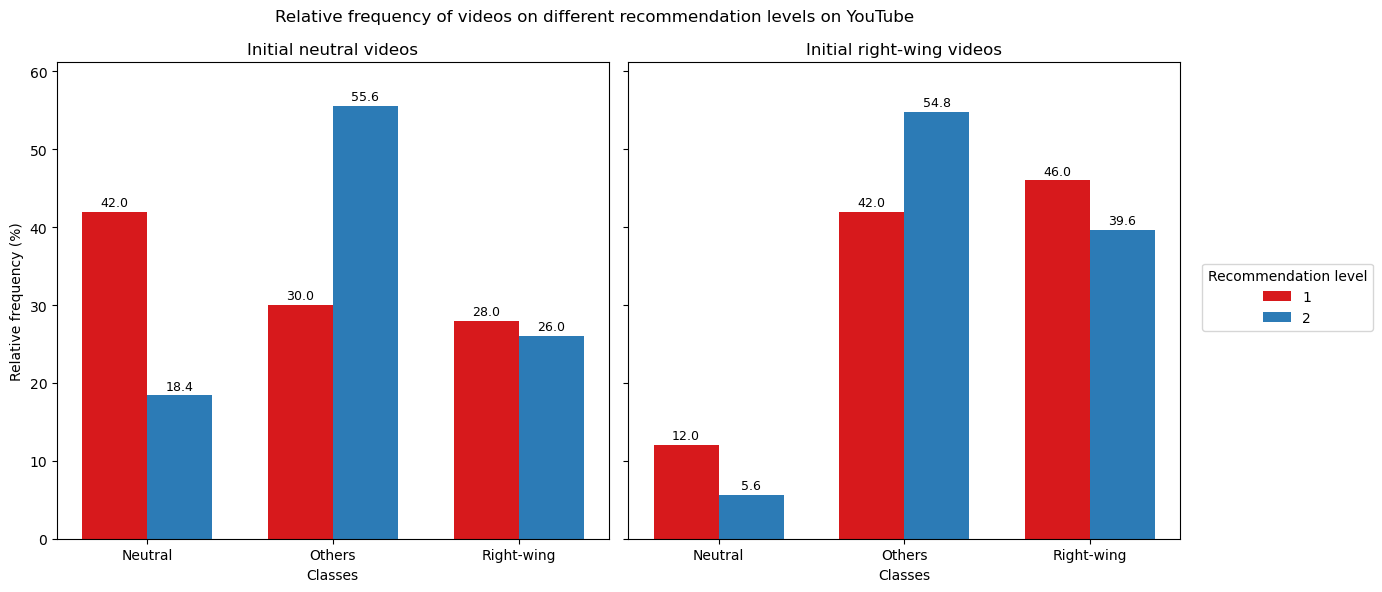

In [12]:
def level_class_frequency(sub):
    data = sub[sub['level'].isin(['first_level', 'second_level'])]
    counts = data.groupby(['level', 'video_stance']).size().unstack(fill_value=0)
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    return pct.reindex(columns=CLASSES, fill_value=0).reindex(['first_level', 'second_level'])

def plot_recommendation_level_frequency(pct_mainstream, pct_right):
    plot_classes = ['Mainstream', 'Other', 'Right']
    display_labels = ['Neutral', 'Others', 'Right-wing']
    colors = ['#d7191c', '#2c7bb6']

    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
    panels = [
        ('Initial neutral videos', pct_mainstream),
        ('Initial right-wing videos', pct_right),
    ]

    for ax, (panel_title, pct) in zip(axes, panels):
        pct = pct.reindex(columns=plot_classes, fill_value=0)
        x = np.arange(len(plot_classes))
        width = 0.35

        for i, level in enumerate(pct.index):
            bars = ax.bar(
                x + (i - 0.5) * width,
                pct.loc[level].values,
                width,
                label=str(i + 1),
                color=colors[i]
            )
            ax.bar_label(bars, fmt='%.1f', padding=2, fontsize=9)

        ax.set_xticks(x)
        ax.set_xticklabels(display_labels)
        ax.set_title(panel_title)
        ax.set_xlabel('Classes')
        ax.margins(y=0.1)

    axes[0].set_ylabel('Relative frequency (%)')
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels, title='Recommendation level',
        loc='center left', bbox_to_anchor=(1.0, 0.5)
    )
    fig.suptitle('Relative frequency of videos on different recommendation levels on YouTube')
    plt.tight_layout()
    plt.show()

pct_level_mainstream = level_class_frequency(sub_mainstream)
pct_level_right = level_class_frequency(sub_right)
plot_recommendation_level_frequency(pct_level_mainstream, pct_level_right)


In [15]:
RANK_COL = 'rank'

def walk_class_frequency(walk_df):
    counts = walk_df.groupby(['step', 'cls']).size().unstack(fill_value=0)
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    return pct.reindex(columns=CLASSES, fill_value=0)

def build_rank_map(sub, rank_col=RANK_COL):
    rank_map = {}
    for row in sub.itertuples(index=False):
        if pd.isna(row.source_video_id):
            continue
        try:
            rank = float(getattr(row, rank_col))
            rank = None if pd.isna(rank) else rank
        except (TypeError, ValueError):
            rank = None
        rank_map[(row.source_video_id, row.video_id)] = rank
    return rank_map

def random_walk_simulation_weighted(
    G, seed_nodes, rank_map, n_runs=5000, max_steps=2, seed=42
):
    rng = random.Random(seed)
    children = defaultdict(list)

    for source, target in G.edges():
        children[source].append((target, rank_map.get((source, target))))

    records = []
    for seed_video in seed_nodes:
        for _ in range(n_runs):
            current = seed_video
            for step in range(1, max_steps + 1):
                options = children.get(current)
                if not options:
                    break
                targets = [target for target, _ in options]
                weights = [
                    1.0 / rank if rank is not None and rank > 0 else 1.0
                    for _, rank in options
                ]
                nxt = rng.choices(targets, weights=weights, k=1)[0]
                records.append({
                    'seed_video_id': seed_video,
                    'step': step,
                    'cls': G.nodes[nxt]['cls'],
                })
                current = nxt

    return pd.DataFrame(records, columns=['seed_video_id', 'step', 'cls'])

seeds_mainstream = sub_mainstream.loc[
    sub_mainstream['level'] == 'seed', 'video_id'
].unique().tolist()
seeds_right = sub_right.loc[
    sub_right['level'] == 'seed', 'video_id'
].unique().tolist()

walk_mainstream_weighted = random_walk_simulation_weighted(
    G_mainstream, seeds_mainstream, build_rank_map(sub_mainstream)
)
walk_right_weighted = random_walk_simulation_weighted(
    G_right, seeds_right, build_rank_map(sub_right)
)

print("=== Mainstream-seed network: RANK-WEIGHTED random walk class % by depth ===")
display(walk_class_frequency(walk_mainstream_weighted).round(2))
print("\n=== Right-seed network: RANK-WEIGHTED random walk class % by depth ===")
display(walk_class_frequency(walk_right_weighted).round(2))
print("\n(对比均匀随机版本，看排名加权后结论是否稳健)")


=== Mainstream-seed network: RANK-WEIGHTED random walk class % by depth ===


cls,Mainstream,Right,Other
step,,,
1,37.00,30.26,32.73
2,16.62,27.23,56.15



=== Right-seed network: RANK-WEIGHTED random walk class % by depth ===


cls,Mainstream,Right,Other
step,,,
1,12.45,47.48,40.07
2,4.32,43.21,52.47



(对比 Section 6 的均匀随机版本,看排名加权后结论是否稳健)


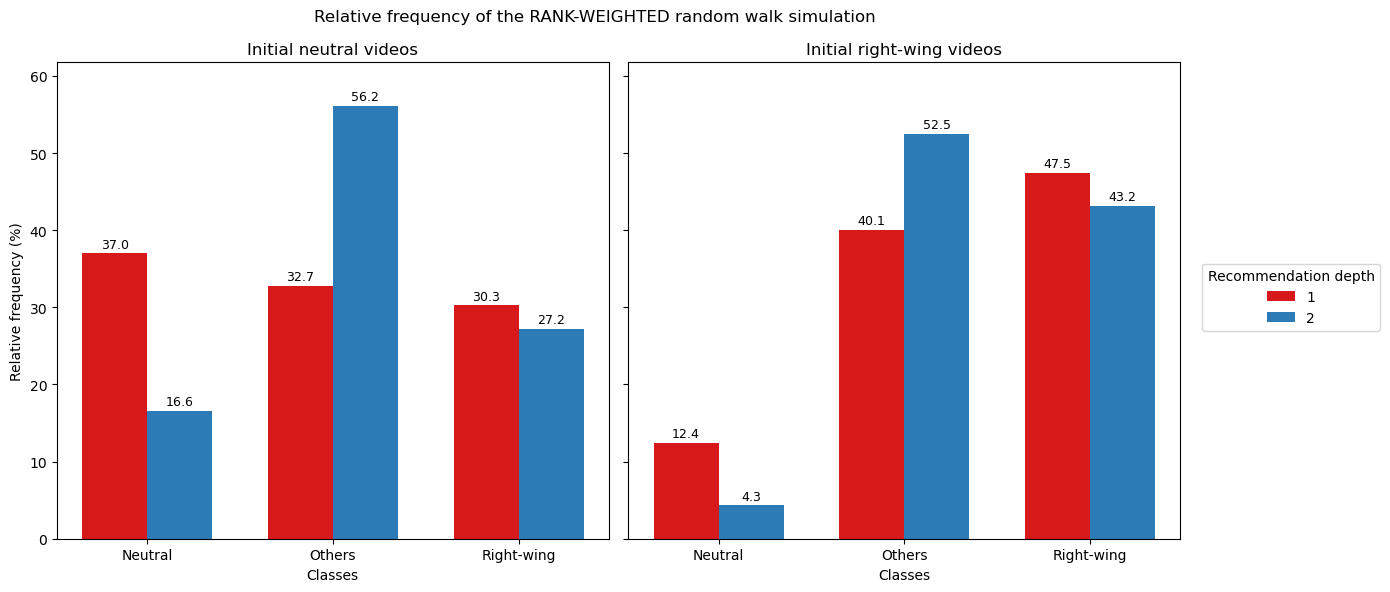

In [16]:
def plot_rank_weighted_frequency(pct_mainstream, pct_right):
    plot_classes = ['Mainstream', 'Other', 'Right']
    display_labels = ['Neutral', 'Others', 'Right-wing']
    colors = ['#d7191c', '#2c7bb6']

    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
    panels = [
        ('Initial neutral videos', pct_mainstream),
        ('Initial right-wing videos', pct_right),
    ]

    for ax, (panel_title, pct) in zip(axes, panels):
        pct = pct.reindex(columns=plot_classes, fill_value=0)
        x = np.arange(len(plot_classes))
        width = 0.35

        for i, depth in enumerate(pct.index):
            bars = ax.bar(
                x + (i - 0.5) * width,
                pct.loc[depth].values,
                width,
                label=str(depth),
                color=colors[i]
            )
            ax.bar_label(bars, fmt='%.1f', padding=2, fontsize=9)

        ax.set_xticks(x)
        ax.set_xticklabels(display_labels)
        ax.set_title(panel_title)
        ax.set_xlabel('Classes')
        ax.margins(y=0.1)

    axes[0].set_ylabel('Relative frequency (%)')
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels, title='Recommendation depth',
        loc='center left', bbox_to_anchor=(1.0, 0.5)
    )
    fig.suptitle('Relative frequency of the RANK-WEIGHTED random walk simulation')
    plt.tight_layout()
    plt.show()

pct_walk_mainstream_weighted = walk_class_frequency(walk_mainstream_weighted)
pct_walk_right_weighted = walk_class_frequency(walk_right_weighted)
plot_rank_weighted_frequency(pct_walk_mainstream_weighted, pct_walk_right_weighted)


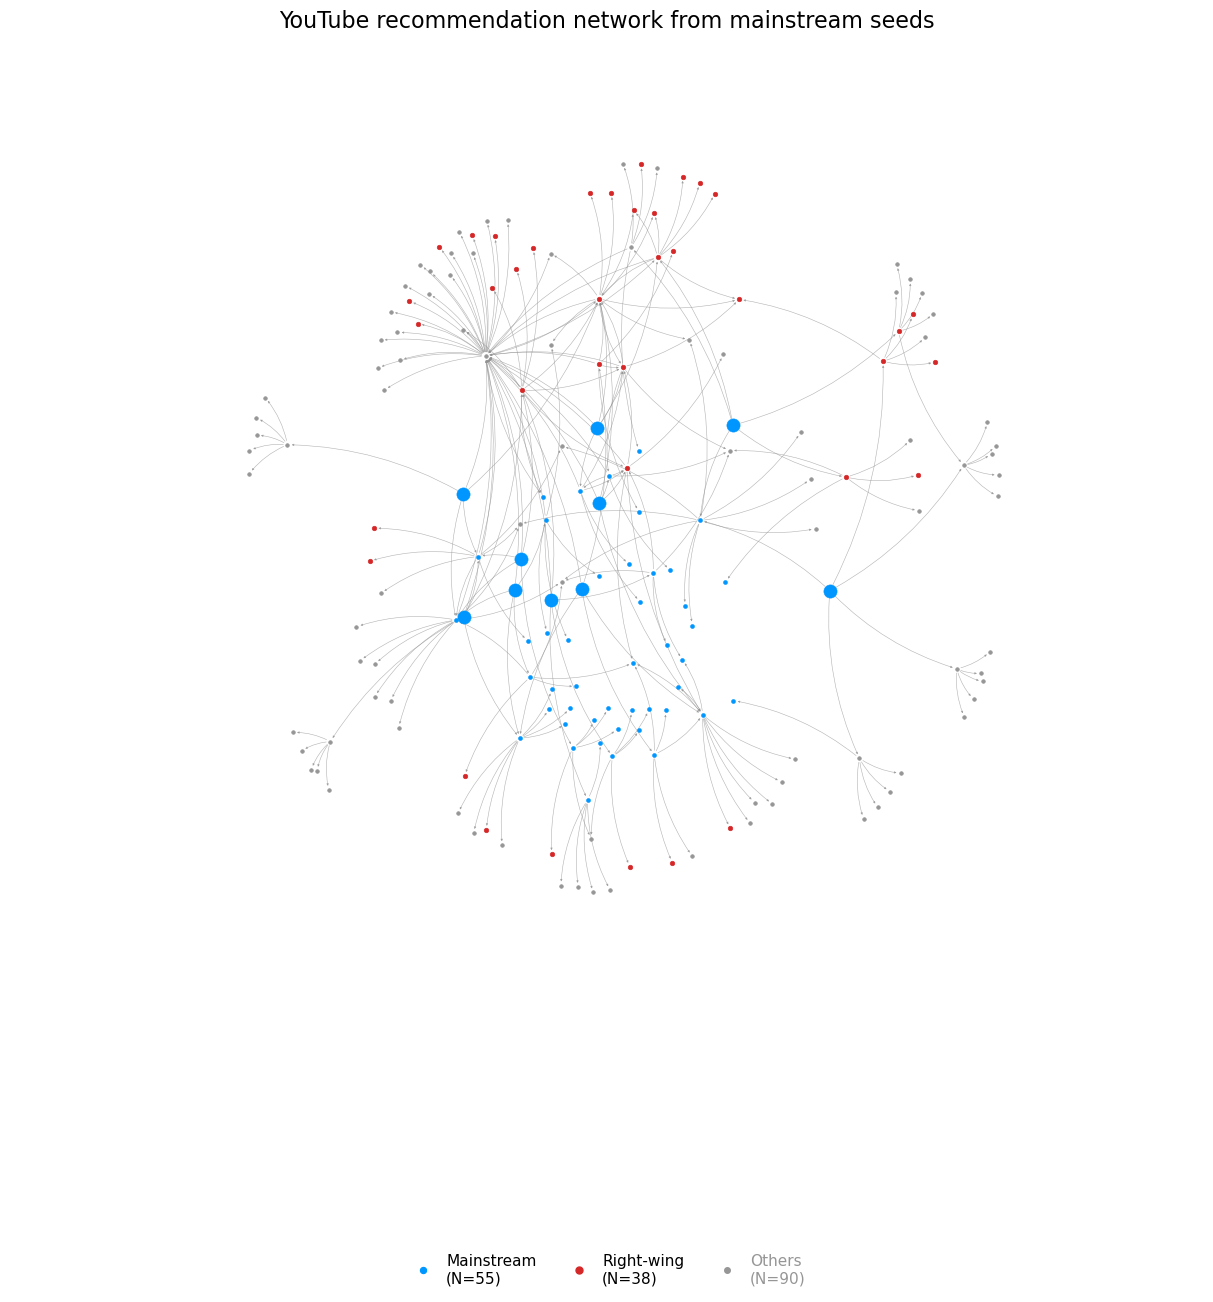

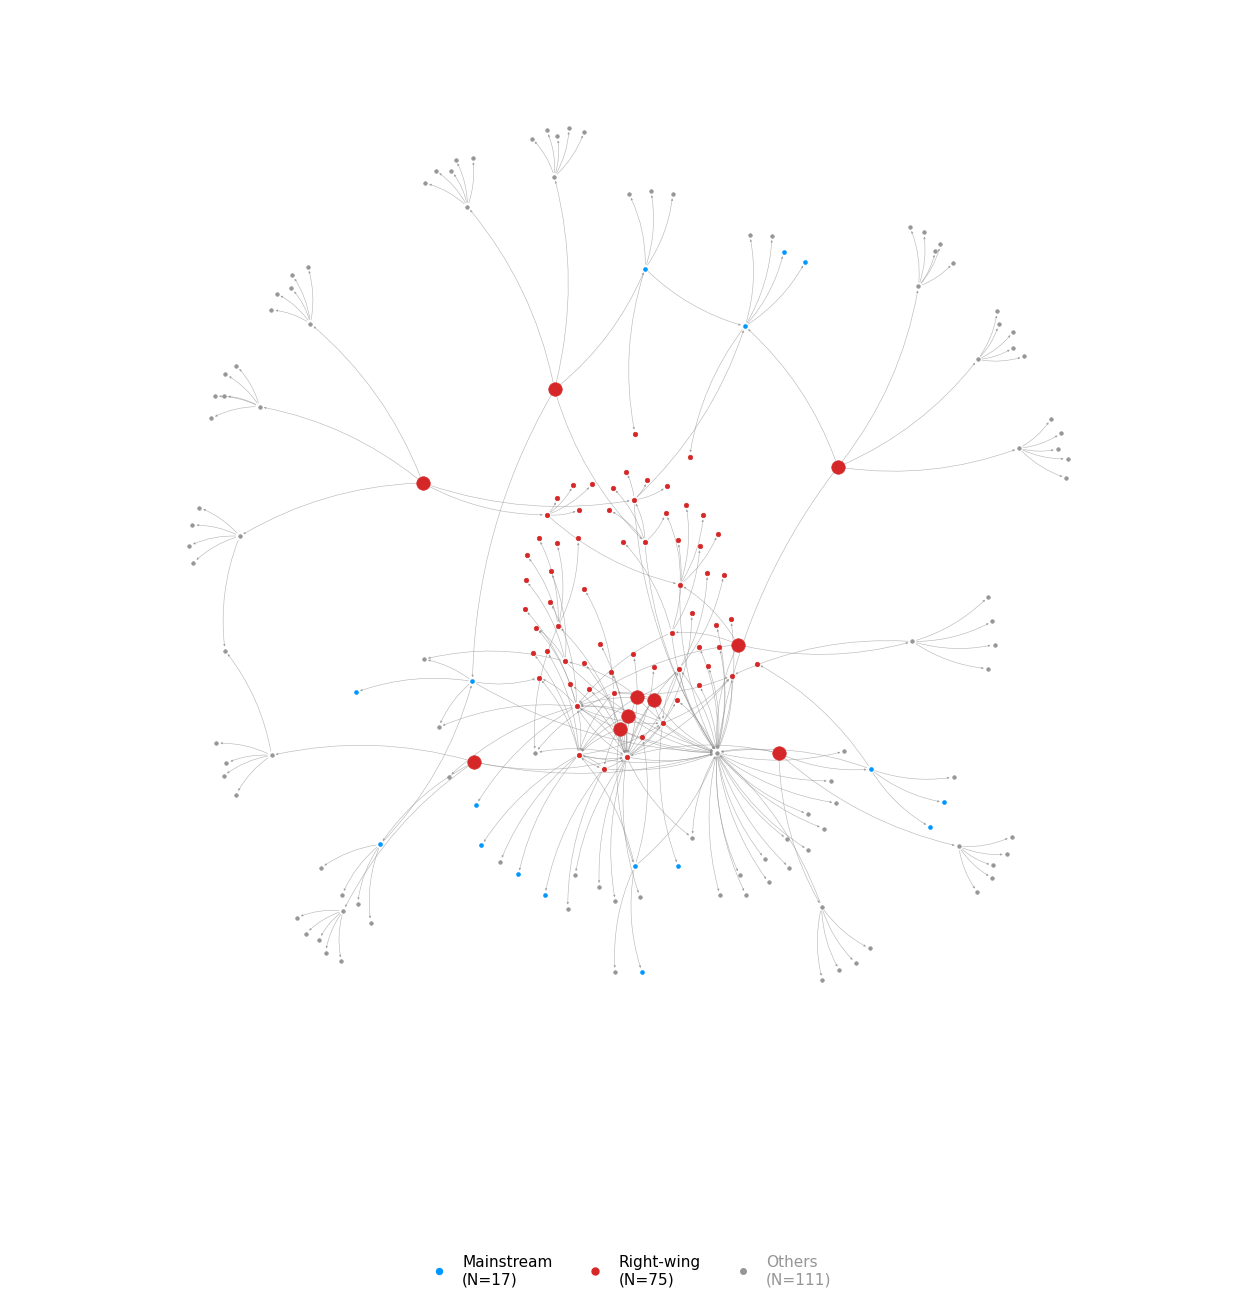

In [17]:
import math
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

NODE_SHAPE = {'Mainstream': 'o', 'Right': 'o', 'Other': 'o'}
NODE_COLOR = {'Mainstream': '#0096FF', 'Right': '#d62728', 'Other': '#969696'}
NODE_EDGECOLOR = {'Mainstream': '#0096FF', 'Right': '#d62728', 'Other': '#969696'}
BASE_SIZE = {'Mainstream': 8, 'Right': 11, 'Other': 7}
SEED_SIZE = {'Mainstream': 90, 'Right': 95, 'Other': 85}

def normalise_level(value):
    v = str(value).strip().lower()
    if v in {'seed', '0', 'level_0', 'level0'}: return 0
    if v in {'1', 'level_1', 'level1', 'first', 'first_level'}: return 1
    if v in {'2', 'level_2', 'level2', 'second', 'second_level'}: return 2
    return None

def get_seed_ids(sub):
    s_ids = set()
    if 'level' in sub.columns:
        s_ids = set(sub.loc[sub['level'].apply(normalise_level) == 0, 'video_id'].dropna())
    if not s_ids and 'seed_video_id' in sub.columns:
        s_ids = set(sub['seed_video_id'].dropna())
    return s_ids

def get_node_size_lookup(G, seed_ids):
    return {n: SEED_SIZE[d.get('cls')] if n in seed_ids else BASE_SIZE[d.get('cls')] for n, d in G.nodes(data=True)}

def build_compact_circular_layout(G, seed=42, iterations=1800, spring_strength=0.42, roundness=1.0, tail_quantile=0.68, centre_expansion=0.92, centre_class=None, centre_pull=3.5, network_scale=0.84):
    layout_graph = G.to_undirected().copy()
    layout_graph.remove_edges_from(nx.selfloop_edges(layout_graph))
    for u, v in layout_graph.edges(): layout_graph[u][v]['layout_weight'] = 1.0

    anchor = '__CENTRE_ANCHOR__'
    while anchor in layout_graph: anchor += '_'
    layout_graph.add_node(anchor)

    if centre_class:
        for node in [n for n, d in G.nodes(data=True) if d.get('cls') == centre_class]:
            layout_graph.add_edge(anchor, node, layout_weight=centre_pull)

    k_val = spring_strength / math.sqrt(max(G.number_of_nodes(), 1))
    rng = np.random.default_rng(seed)
    init_pos = {n: rng.normal(0, 0.20, 2) for n in layout_graph.nodes()}
    init_pos[anchor] = np.array([0.0, 0.0])

    raw_pos = nx.spring_layout(layout_graph, pos=init_pos, fixed=[anchor], seed=seed, iterations=iterations, k=k_val, weight='layout_weight', center=(0.0, 0.0))
    raw_pos.pop(anchor, None)
    
    nodes = list(G.nodes())
    if not nodes: return {}

    xy = np.array([raw_pos[n] for n in nodes], dtype=float)
    xy -= xy.mean(axis=0)

    if len(nodes) > 1:
        evals, evecs = np.linalg.eigh(np.cov(xy.T))
        xy = xy @ evecs[:, np.argsort(evals)[::-1]]

    x_std, y_std = xy[:, 0].std(), xy[:, 1].std()
    t_std = math.sqrt(max(x_std, 1e-10) * max(y_std, 1e-10))
    circ_xy = xy.copy()
    if x_std > 0: circ_xy[:, 0] *= (t_std / x_std)
    if y_std > 0: circ_xy[:, 1] *= (t_std / y_std)
    xy = (1.0 - roundness) * xy + roundness * circ_xy

    radii = np.linalg.norm(xy, axis=1)
    if (pos_r := radii[radii > 0]).size > 0:
        ref_r = max(np.quantile(pos_r, tail_quantile), 1e-10)
        xy *= np.divide(ref_r * np.tanh(radii / ref_r), radii, out=np.ones_like(radii), where=radii > 0)[:, None]

    radii = np.linalg.norm(xy, axis=1)
    if (max_r := radii.max()) > 0:
        norm_r = radii / max_r
        xy *= np.divide(norm_r ** centre_expansion, norm_r, out=np.ones_like(norm_r), where=norm_r > 0)[:, None]

    if centre_class and (c_idx := [i for i, n in enumerate(nodes) if G.nodes[n].get('cls') == centre_class]):
        xy -= xy[c_idx].mean(axis=0)
    else:
        xy -= xy.mean(axis=0)

    radii = np.linalg.norm(xy, axis=1)
    if (max_r := radii.max()) > 0: xy /= max_r
    if (out := np.linalg.norm(xy, axis=1) > 1.0).any(): xy[out] *= (1.0 / np.linalg.norm(xy[out], axis=1))[:, None]

    return {n: tuple(p) for n, p in zip(nodes, xy * network_scale)}

def draw_clockwise_curved_edges(G, pos, ax, node_size_lookup, curvature=0.13, edge_color='#929292', width=0.42, alpha=0.68):
    nx.draw_networkx_edges(G, pos, edgelist=list(G.edges()), ax=ax, edge_color=edge_color, width=width, alpha=alpha, arrows=G.is_directed(), arrowstyle='-|>', arrowsize=3.0, connectionstyle=f'arc3,rad={curvature}', node_size=[node_size_lookup[n] for n in G.nodes()], min_source_margin=3, min_target_margin=3)

def draw_recommendation_network(G, sub, title, centre_class, savepath=None, figsize=(13, 13), seed=42, spring_strength=0.42, roundness=1.0, tail_quantile=0.68, centre_expansion=0.92, centre_pull=3.5, network_scale=0.84, edge_curvature=0.13):
    seed_ids = get_seed_ids(sub)
    ns_lookup = get_node_size_lookup(G, seed_ids)
    pos = build_compact_circular_layout(G, seed=seed, spring_strength=spring_strength, roundness=roundness, tail_quantile=tail_quantile, centre_expansion=centre_expansion, centre_class=centre_class, centre_pull=centre_pull, network_scale=network_scale)

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor('white'); ax.set_facecolor('white')
    draw_clockwise_curved_edges(G, pos, ax, ns_lookup, curvature=edge_curvature)

    for cls in ['Mainstream', 'Right', 'Other']:
        if n_list := [n for n in G.nodes() if n not in seed_ids and G.nodes[n].get('cls') == cls]:
            nx.draw_networkx_nodes(G, pos, nodelist=n_list, ax=ax, node_shape=NODE_SHAPE[cls], node_color=NODE_COLOR[cls], node_size=BASE_SIZE[cls], edgecolors=NODE_EDGECOLOR[cls], linewidths=0.42)
        if s_list := [n for n in seed_ids if n in G and G.nodes[n].get('cls') == cls]:
            nx.draw_networkx_nodes(G, pos, nodelist=s_list, ax=ax, node_shape=NODE_SHAPE[cls], node_color=NODE_COLOR[cls], node_size=SEED_SIZE[cls], edgecolors=NODE_EDGECOLOR[cls], linewidths=0.42)

    counts = sub.drop_duplicates('video_id')['video_stance'].value_counts()
    handles = [
        Line2D([0], [0], marker='o', ls='None', markerfacecolor='#0096FF', markeredgecolor='#0096FF', markeredgewidth=0.8, markersize=4.5, label=f"Mainstream\n(N={counts.get('Mainstream', 0)})"),
        Line2D([0], [0], marker='o', ls='None', markerfacecolor='#d62728', markeredgecolor='#d62728', markersize=5, label=f"Right-wing\n(N={counts.get('Right', 0)})"),
        Line2D([0], [0], marker='o', ls='None', markerfacecolor="#969696", markeredgecolor="#969696", markersize=4, label=f"Others\n(N={counts.get('Other', 0)})")
    ]
    leg = ax.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.055), ncol=3, frameon=False, fontsize=11, handletextpad=0.5, columnspacing=1.8)
    if len(leg.get_texts()) >= 3: leg.get_texts()[2].set_color('#969696')

    ax.set_title(title, fontsize=16, fontweight='normal', pad=18)
    ax.set_aspect('equal', adjustable='box')
    ax.set(xlim=(-1.08, 1.08), ylim=(-1.10, 1.04))
    ax.axis('off')
    plt.tight_layout()
    if savepath: plt.savefig(savepath, dpi=300, bbox_inches='tight', facecolor='white')
    return fig, ax

draw_recommendation_network(
    G_mainstream, sub_mainstream, 
    title="YouTube recommendation network from mainstream seeds", 
    centre_class='Mainstream', 
    savepath="../SRQ1 Network recommendation_data/rec_network_mainstream.png"
)
plt.show()

draw_recommendation_network(
    G_right, sub_right, 
    title="", 
    centre_class='Right', 
    savepath="../SRQ1 Network recommendation_data/rec_network_right.png"
)
plt.show()

In [19]:
video_class_all = (
    df.groupby('video_id')['video_stance']
      .agg(lambda x: x.mode().iloc[0])
      .to_dict()
)

G_all = nx.DiGraph()
G_all.add_nodes_from((vid, {'cls': stance}) for vid, stance in video_class_all.items())

for row in df.itertuples(index=False):
    if pd.notna(row.source_video_id) and row.source_video_id in G_all:
        G_all.add_edge(row.source_video_id, row.video_id)

print(
    f"Combined network (all seed_stance merged): "
    f"{G_all.number_of_nodes()} nodes, {G_all.number_of_edges()} edges"
)

def per_video_ei_index(G, video_id):
    own_class = G.nodes[video_id]['cls']
    neighbours = [nbr for _, nbr in G.out_edges(video_id)]
    neighbours += [nbr for nbr, _ in G.in_edges(video_id)]

    internal = sum(G.nodes[nbr]['cls'] == own_class for nbr in neighbours)
    external = len(neighbours) - internal
    total = internal + external
    ei = (external - internal) / total if total else np.nan
    return internal, external, ei

focal_video_ids = (
    df.loc[df['level'].isin(['seed', 'first_level']), 'video_id']
      .dropna()
      .drop_duplicates()
)

rows = []
for video_id in focal_video_ids:
    if video_id not in G_all:
        continue
    internal, external, ei = per_video_ei_index(G_all, video_id)
    rows.append({
        'video_id': video_id,
        'EI_index': ei,
        'video_stance': G_all.nodes[video_id]['cls'],
        'internal_ties': internal,
        'external_ties': external,
        'total_ties': internal + external,
    })

video_ei_df = (
    pd.DataFrame(rows)
      .sort_values(['video_stance', 'video_id'], na_position='last')
      .reset_index(drop=True)
)

OUTPUT_CSV_PATH = '../SRQ1 Network recommendation_data/video_level_ei_index.csv'
video_ei_df.to_csv(OUTPUT_CSV_PATH, index=False)

print(
    f"Computed E-I index for {len(video_ei_df)} videos "
    f"(seed + first_level, including Other)"
)
print("\nNumber of focal videos by stance:")
print(video_ei_df['video_stance'].value_counts(dropna=False))
print(f"\nSaved to: {OUTPUT_CSV_PATH}")

video_ei_df


Combined network (all seed_stance merged): 336 nodes, 471 edges
Computed E-I index for 76 videos (seed + first_level, including Other)

Number of focal videos by stance:
video_stance
Right         29
Mainstream    27
Other         20
Name: count, dtype: int64

Saved to: ../SRQ1 Network recommendation_data/video_level_ei_index.csv


,video_id,EI_index,video_stance,internal_ties,external_ties,total_ties
0,191CuNRGoos,-0.333333,Mainstream,4,2,6
1,7KI3ipbzpvU,0.111111,Mainstream,4,5,9
2,A-zFK_LPxJI,0.600000,Mainstream,1,4,5
3,AC1oVk79HtU,0.272727,Mainstream,4,7,11
4,DSbWRvKyIuE,0.200000,Mainstream,2,3,5
...,...,...,...,...,...,...
71,sJpcNWlmrDs,-0.636364,Right,9,2,11
72,vUj2wkzSoB4,0.666667,Right,1,5,6
73,x3eDp0usbJI,-0.333333,Right,26,13,39
74,z-Zo6PPVdwE,1.000000,Right,0,6,6
